import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:


df=pd.read_csv('Nifty_50_data.csv')


In [3]:

df

,Date,Price,Open,High,Low,Vol.,Change %
0,31-08-2026,"24,080.40","24,117.55","24,117.55","23,993.85",710.87M,-0.39%
1,28-08-2026,"24,175.65","24,122.60","24,188.30","24,076.85",296.13M,0.35%
2,27-08-2026,"24,090.85","24,277.60","24,297.45","24,090.85",323.42M,-0.48%
3,26-08-2026,"24,207.75","24,341.95","24,378.60","24,207.75",244.79M,-0.52%
4,25-08-2026,"24,334.55","24,175.75","24,334.55","24,115.45",239.45M,0.48%
...,...,...,...,...,...,...,...
2473,07-09-2016,"8,917.95","8,968.70","8,968.70","8,913.35",299.15M,-0.28%
2474,06-09-2016,"8,943.00","8,852.70","8,950.85","8,848.45",201.62M,1.51%
2475,02-09-2016,"8,809.65","8,796.35","8,824.10","8,768.20",197.38M,0.40%
2476,01-09-2016,"8,774.65","8,793.60","8,813.25","8,759.95",246.34M,-0.13%


In [4]:
print("shape",df.shape)




shape (2478, 7)


In [5]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2478 entries, 0 to 2477
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      2478 non-null   object
 1   Price     2478 non-null   object
 2   Open      2478 non-null   object
 3   High      2478 non-null   object
 4   Low       2478 non-null   object
 5   Vol.      2474 non-null   object
 6   Change %  2478 non-null   object
dtypes: object(7)
memory usage: 135.6+ KB


In [6]:

df['Date']=pd.to_datetime(df['Date'],dayfirst=True)


In [7]:
df

,Date,Price,Open,High,Low,Vol.,Change %
0,2026-08-31,"24,080.40","24,117.55","24,117.55","23,993.85",710.87M,-0.39%
1,2026-08-28,"24,175.65","24,122.60","24,188.30","24,076.85",296.13M,0.35%
2,2026-08-27,"24,090.85","24,277.60","24,297.45","24,090.85",323.42M,-0.48%
3,2026-08-26,"24,207.75","24,341.95","24,378.60","24,207.75",244.79M,-0.52%
4,2026-08-25,"24,334.55","24,175.75","24,334.55","24,115.45",239.45M,0.48%
...,...,...,...,...,...,...,...
2473,2016-09-07,"8,917.95","8,968.70","8,968.70","8,913.35",299.15M,-0.28%
2474,2016-09-06,"8,943.00","8,852.70","8,950.85","8,848.45",201.62M,1.51%
2475,2016-09-02,"8,809.65","8,796.35","8,824.10","8,768.20",197.38M,0.40%
2476,2016-09-01,"8,774.65","8,793.60","8,813.25","8,759.95",246.34M,-0.13%


In [8]:

df['Date'].head(10).to_list()

[Timestamp('2026-08-31 00:00:00'),
 Timestamp('2026-08-28 00:00:00'),
 Timestamp('2026-08-27 00:00:00'),
 Timestamp('2026-08-26 00:00:00'),
 Timestamp('2026-08-25 00:00:00'),
 Timestamp('2026-08-24 00:00:00'),
 Timestamp('2026-08-21 00:00:00'),
 Timestamp('2026-08-20 00:00:00'),
 Timestamp('2026-08-19 00:00:00'),
 Timestamp('2026-08-18 00:00:00')]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2478 entries, 0 to 2477
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2478 non-null   datetime64[ns]
 1   Price     2478 non-null   object        
 2   Open      2478 non-null   object        
 3   High      2478 non-null   object        
 4   Low       2478 non-null   object        
 5   Vol.      2474 non-null   object        
 6   Change %  2478 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 135.6+ KB


In [10]:
numeric_columns=['Price','Open','High','Low']
for col in numeric_columns:
    df[col]=df[col].str.replace(',','',regex=False)
    df[col]=pd.to_numeric(df[col],errors='coerce')
    
df['Vol.']=df['Vol.'].str.replace('M','',regex=False)
df['Vol.']=pd.to_numeric(df['Vol.'],errors='coerce')

df['Change %']=df['Change %'].str.replace('%','',regex=False)
df['Change %']=pd.to_numeric(df['Change %'],errors='coerce')




In [11]:


df=df.sort_values('Date')

In [12]:
df=df.reset_index(drop=True)

In [13]:
df.head(7)

,Date,Price,Open,High,Low,Vol.,Change %
0,2016-08-31,8786.20,8754.05,8819.20,8754.05,373.42,0.48
1,2016-09-01,8774.65,8793.60,8813.25,8759.95,246.34,-0.13
2,2016-09-02,8809.65,8796.35,8824.10,8768.20,197.38,0.40
3,2016-09-06,8943.00,8852.70,8950.85,8848.45,201.62,1.51
4,2016-09-07,8917.95,8968.70,8968.70,8913.35,299.15,-0.28
5,2016-09-08,8952.50,8915.50,8960.35,8896.00,223.94,0.39
6,2016-09-09,8866.70,8934.30,8939.15,8858.70,181.34,-0.96


In [14]:
df.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,2478,2478.000000,2478.000000,2478.000000,2478.000000,2456.000000,2478.000000
mean,2021-09-01 01:20:11.622276096,16221.651877,16231.215638,16304.188761,16135.938761,348.879324,0.046190
min,2016-08-31 00:00:00,7610.250000,7735.150000,7970.050000,7511.100000,2.830000,-12.980000
25%,2019-02-28 06:00:00,10845.462500,10860.050000,10897.800000,10787.525000,232.910000,-0.420000
50%,2021-09-01 12:00:00,15923.800000,15921.800000,16027.250000,15838.525000,296.295000,0.060000
75%,2024-02-28 18:00:00,22030.062500,22017.637500,22130.175000,21913.300000,427.665000,0.570000
max,2026-08-31 00:00:00,26328.550000,26333.700000,26373.200000,26210.050000,997.650000,8.760000
std,NaN,5722.531881,5721.832413,5743.128574,5701.103820,165.477949,1.019755


df.isnull().sum()

In [15]:
df=df.dropna(subset='Vol.')

In [16]:
df.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [17]:
df

,Date,Price,Open,High,Low,Vol.,Change %
0,2016-08-31,8786.20,8754.05,8819.20,8754.05,373.42,0.48
1,2016-09-01,8774.65,8793.60,8813.25,8759.95,246.34,-0.13
2,2016-09-02,8809.65,8796.35,8824.10,8768.20,197.38,0.40
3,2016-09-06,8943.00,8852.70,8950.85,8848.45,201.62,1.51
4,2016-09-07,8917.95,8968.70,8968.70,8913.35,299.15,-0.28
...,...,...,...,...,...,...,...
2473,2026-08-25,24334.55,24175.75,24334.55,24115.45,239.45,0.48
2474,2026-08-26,24207.75,24341.95,24378.60,24207.75,244.79,-0.52
2475,2026-08-27,24090.85,24277.60,24297.45,24090.85,323.42,-0.48
2476,2026-08-28,24175.65,24122.60,24188.30,24076.85,296.13,0.35


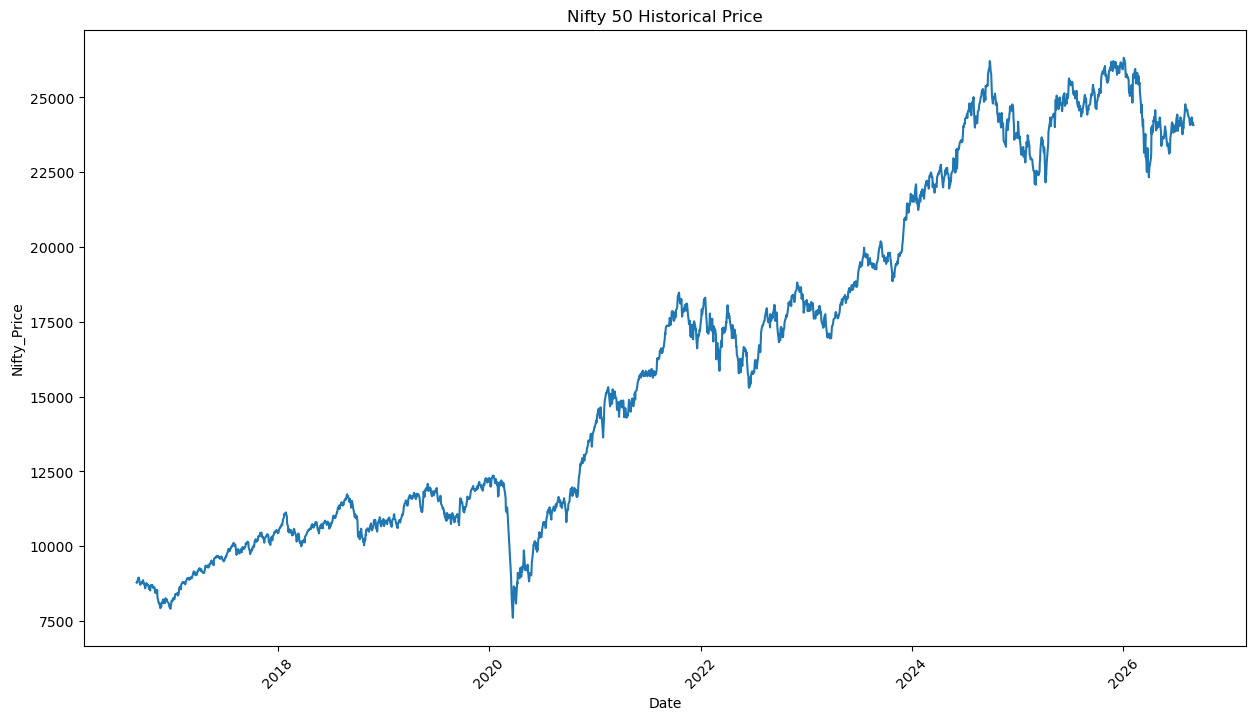

In [18]:
plt.figure(figsize=(15,8))

plt.plot(df['Date'],df['Price'])

plt.xlabel('Date')
plt.ylabel('Nifty_Price')
plt.title('Nifty 50 Historical Price')
plt.xticks(rotation=45)
plt.show()

In [19]:
df['Previous_Price']=df['Price'].shift(1)

In [20]:
df.head(10)

,Date,Price,Open,High,Low,Vol.,Change %,Previous_Price
0,2016-08-31,8786.20,8754.05,8819.20,8754.05,373.42,0.48,NaN
1,2016-09-01,8774.65,8793.60,8813.25,8759.95,246.34,-0.13,8786.20
2,2016-09-02,8809.65,8796.35,8824.10,8768.20,197.38,0.40,8774.65
3,2016-09-06,8943.00,8852.70,8950.85,8848.45,201.62,1.51,8809.65
4,2016-09-07,8917.95,8968.70,8968.70,8913.35,299.15,-0.28,8943.00
5,2016-09-08,8952.50,8915.50,8960.35,8896.00,223.94,0.39,8917.95
6,2016-09-09,8866.70,8934.30,8939.15,8858.70,181.34,-0.96,8952.50
7,2016-09-12,8715.60,8732.95,8746.95,8699.40,190.20,-1.70,8866.70
8,2016-09-14,8726.60,8710.65,8739.85,8688.90,189.98,0.13,8715.60
9,2016-09-15,8742.55,8743.85,8751.95,8704.35,149.89,0.18,8726.60


In [21]:
df['High_Low_Diff']=df['High']-df['Low']

In [22]:
df['Open_Close_Diff']=df['Price']-df['Open']

In [23]:
df['Target']=df['Price'].shift(-1)

In [24]:
df

,Date,Price,Open,High,Low,Vol.,Change %,Previous_Price,High_Low_Diff,Open_Close_Diff,Target
0,2016-08-31,8786.20,8754.05,8819.20,8754.05,373.42,0.48,NaN,65.15,32.15,8774.65
1,2016-09-01,8774.65,8793.60,8813.25,8759.95,246.34,-0.13,8786.20,53.30,-18.95,8809.65
2,2016-09-02,8809.65,8796.35,8824.10,8768.20,197.38,0.40,8774.65,55.90,13.30,8943.00
3,2016-09-06,8943.00,8852.70,8950.85,8848.45,201.62,1.51,8809.65,102.40,90.30,8917.95
4,2016-09-07,8917.95,8968.70,8968.70,8913.35,299.15,-0.28,8943.00,55.35,-50.75,8952.50
...,...,...,...,...,...,...,...,...,...,...,...
2473,2026-08-25,24334.55,24175.75,24334.55,24115.45,239.45,0.48,24219.05,219.10,158.80,24207.75
2474,2026-08-26,24207.75,24341.95,24378.60,24207.75,244.79,-0.52,24334.55,170.85,-134.20,24090.85
2475,2026-08-27,24090.85,24277.60,24297.45,24090.85,323.42,-0.48,24207.75,206.60,-186.75,24175.65
2476,2026-08-28,24175.65,24122.60,24188.30,24076.85,296.13,0.35,24090.85,111.45,53.05,24080.40


In [25]:
df=df.dropna()
df=df.reset_index(drop=True)
df

,Date,Price,Open,High,Low,Vol.,Change %,Previous_Price,High_Low_Diff,Open_Close_Diff,Target
0,2016-09-01,8774.65,8793.60,8813.25,8759.95,246.34,-0.13,8786.20,53.30,-18.95,8809.65
1,2016-09-02,8809.65,8796.35,8824.10,8768.20,197.38,0.40,8774.65,55.90,13.30,8943.00
2,2016-09-06,8943.00,8852.70,8950.85,8848.45,201.62,1.51,8809.65,102.40,90.30,8917.95
3,2016-09-07,8917.95,8968.70,8968.70,8913.35,299.15,-0.28,8943.00,55.35,-50.75,8952.50
4,2016-09-08,8952.50,8915.50,8960.35,8896.00,223.94,0.39,8917.95,64.35,37.00,8866.70
...,...,...,...,...,...,...,...,...,...,...,...
2449,2026-08-24,24219.05,24285.05,24313.00,24144.30,236.29,-0.14,24252.00,168.70,-66.00,24334.55
2450,2026-08-25,24334.55,24175.75,24334.55,24115.45,239.45,0.48,24219.05,219.10,158.80,24207.75
2451,2026-08-26,24207.75,24341.95,24378.60,24207.75,244.79,-0.52,24334.55,170.85,-134.20,24090.85
2452,2026-08-27,24090.85,24277.60,24297.45,24090.85,323.42,-0.48,24207.75,206.60,-186.75,24175.65


In [26]:
df.isnull().sum()
df=df.dropna()

In [27]:
features=['Price','Open','High','Low','Vol.','Change %','Previous_Price','High_Low_Diff','Open_Close_Diff']

X=df[features]
Y=df['Target']

In [28]:
split=int(len(df)*0.8)

X_train= X.iloc[:split]
X_test=X.iloc[split:]

Y_train=Y.iloc[:split]
Y_test=Y.iloc[split:]

print("Train Data:",X_train.shape)
print("Test Data",X_test.shape)


Train Data: (1963, 9)
Test Data (491, 9)


In [29]:
##..............................Linear Regression MOdel.................................

In [30]:
Ir_model=LinearRegression()

Ir_model.fit(X_train,Y_train)

Ir_pred=Ir_model.predict(X_test)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, Y_train)

lr_pred = lr_model.predict(X_test_scaled)


In [32]:
Ir_mae=mean_absolute_error(Y_test,Ir_pred)
Ir_rsme=np.sqrt(mean_squared_error(Y_test,Ir_pred))
Ir_r2=r2_score(Y_test,Ir_pred)

print("Linear Regression")
print("MAE: ",Ir_mae)
print("RSME: ", Ir_rsme)
print("R2: ", Ir_r2)

Linear Regression
MAE:  151.3596100995847
RSME:  203.020950483431
R2:  0.9566027107022649


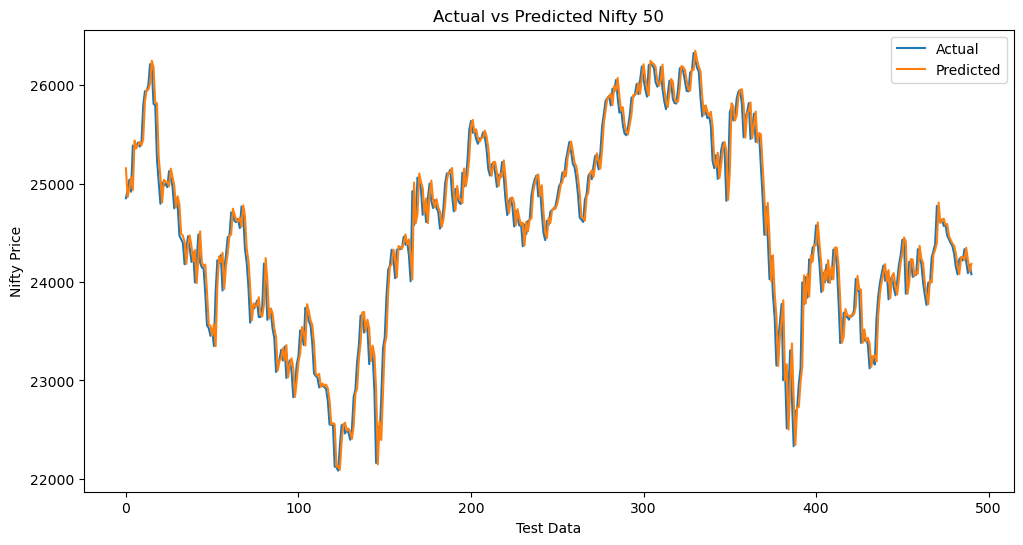

In [33]:
plt.figure(figsize=(12,6))

plt.plot(Y_test.values,label="Actual")
plt.plot(Ir_pred,label="Predicted")

plt.title("Actual vs Predicted Nifty 50")
plt.xlabel("Test Data")
plt.ylabel("Nifty Price")
plt.legend()
plt.show()

In [34]:
print("Actual")
print(Y_test.head(10))

print("\nPredicted:")
print(Ir_pred[:10])

Actual
1963    24852.15
1964    24936.40
1965    25041.10
1966    24918.45
1967    25388.90
1968    25356.50
1969    25383.75
1970    25418.55
1971    25377.55
1972    25415.80
Name: Target, dtype: float64

Predicted:
[25156.85082786 24864.7936297  24949.62884205 25063.37306801
 24935.37779538 25438.11238469 25359.10484644 25395.48271205
 25424.68719856 25389.22320871]


In [35]:
##...........................Decision Tree Model.................................

In [36]:
dt_model=DecisionTreeRegressor(
    max_depth=10,
    random_state=42
    
)
dt_model.fit(X_train,Y_train)
dt_pred=dt_model.predict(X_test)

In [37]:
print("Decision Tree")
print("MAE: ",mean_absolute_error(Y_test,dt_pred))
print("RSME: ",np.sqrt(mean_squared_error(Y_test,dt_pred)))
print("R2_Score: ",r2_score(Y_test,dt_pred))

Decision Tree
MAE:  302.08678680535354
RSME:  395.39041756295677
R2_Score:  0.8353987346328722


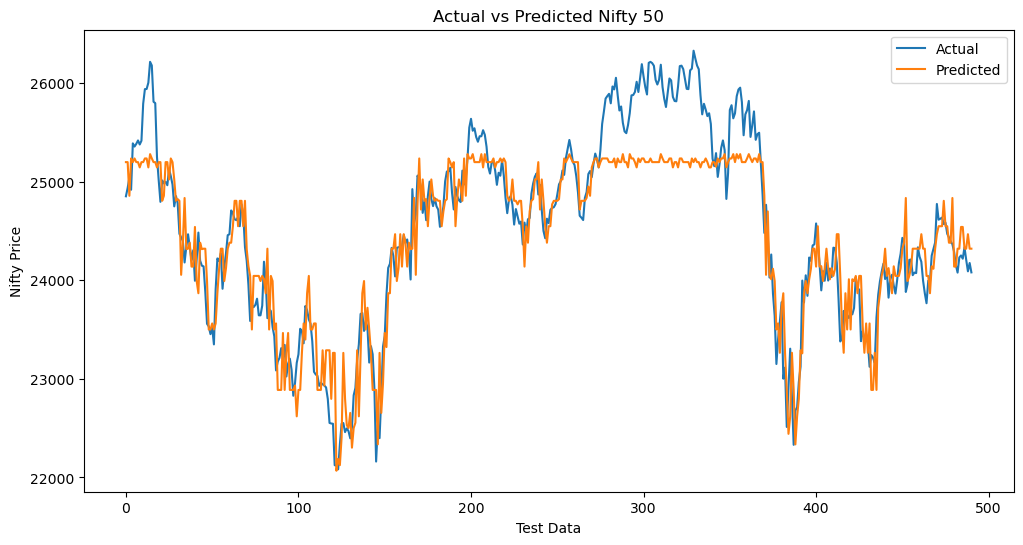

In [38]:
plt.figure(figsize=(12,6))

plt.plot(Y_test.values,label="Actual")
plt.plot(dt_pred,label="Predicted")

plt.title("Actual vs Predicted Nifty 50")
plt.xlabel("Test Data")
plt.ylabel("Nifty Price")
plt.legend()
plt.show()



In [39]:
##.................................Random Forest MOdel.........................

print("Actual")
print(Y_test.head(10))

print("\nPredicted:")
print(dt_pred[:10])

In [40]:
rf_model=RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42  
)
rf_model.fit(X_train,Y_train)
rf_pred=rf_model.predict(X_test)

In [41]:
print("Random Forest")
print("MAE: ",mean_absolute_error(Y_test,rf_pred))
print("RSME: ",np.sqrt(mean_squared_error(Y_test,rf_pred)))
print("R2 Score: ", r2_score(Y_test,rf_pred))

Random Forest
MAE:  272.1631874034241
RSME:  374.1383698289365
R2 Score:  0.8526176798233982


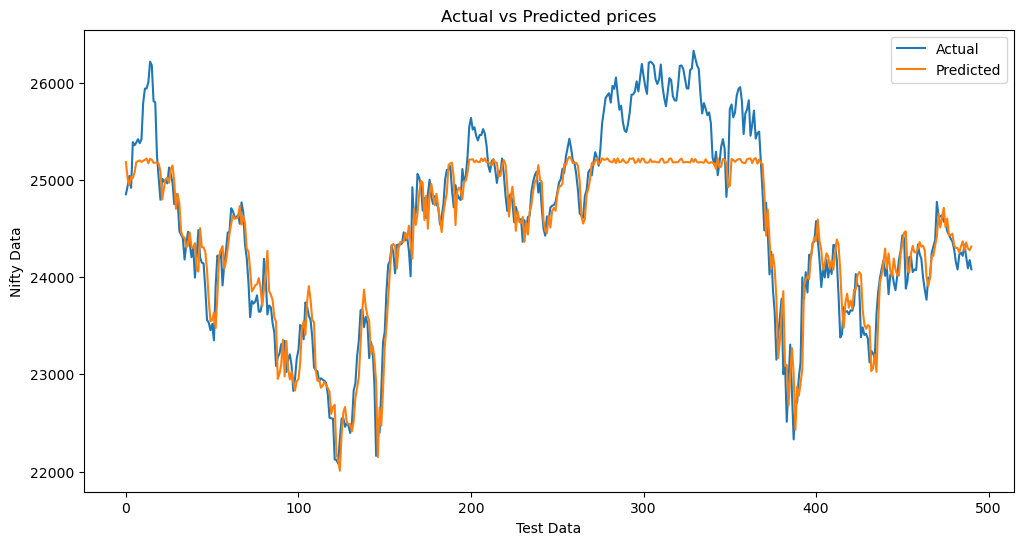

In [42]:
plt.figure(figsize=(12,6))
plt.plot(Y_test.values,label="Actual")
plt.plot(rf_pred,label="Predicted")

plt.title("Actual vs Predicted prices")
plt.xlabel("Test Data")
plt.ylabel("Nifty Data")
plt.legend()
plt.show()

In [43]:
print("Actual: ", Y_test.head(10))
print("Predicted: ", rf_pred[:10])

Actual:  1963    24852.15
1964    24936.40
1965    25041.10
1966    24918.45
1967    25388.90
1968    25356.50
1969    25383.75
1970    25418.55
1971    25377.55
1972    25415.80
Name: Target, dtype: float64
Predicted:  [25182.42       25010.48675    24946.58465417 25031.63960417
 25018.723      25075.58766667 25182.26       25192.48275
 25200.14175    25184.5125    ]


In [44]:
def predict_nifty(price, open_price, high, low, volume, previous_price):

    change_pct = ((price - previous_price) / previous_price) * 100
    high_low_diff = high - low
    open_close_diff = price - open_price

    input_data = pd.DataFrame([[
        price,
        open_price,
        high,
        low,
        volume,
        change_pct,
        previous_price,
        high_low_diff,
        open_close_diff
    ]],columns=features)
    
    input_scaled = scaler.transform(input_data)

    prediction = lr_model.predict(input_scaled)[0]


    
    return prediction
    

In [45]:
price = float(input("Current Price: "))
open_price = float(input("Open: "))
high = float(input("High: "))
low = float(input("Low: "))
volume = float(input("Volume: "))
previous_price = float(input("Previous Price: "))

prediction = predict_nifty(
    price,
    open_price,
    high,
    low,
    volume,
    previous_price
)

print("\nPredicted Next-Day Price:", round(prediction, 2))
print("Current Price:", round(price, 2))
print("Expected Change %:", round(((prediction-price)/price)*100, 2))

Current Price:  23477.80
Open:  23446.60
High:  23494.95
Low:  23380.10
Volume:  253.25
Previous Price:  23431.50



Predicted Next-Day Price: 23484.09
Current Price: 23477.8
Expected Change %: 0.03


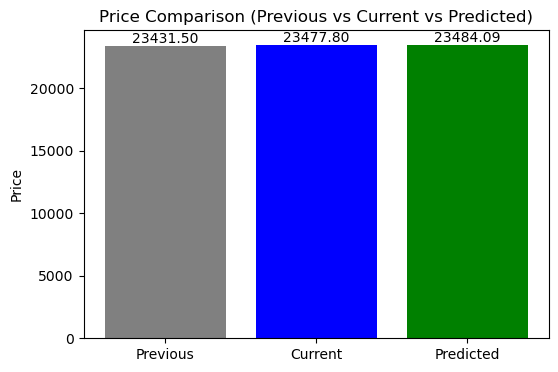

In [46]:
labels = ['Previous', 'Current', 'Predicted']
values = [previous_price, price, prediction]
colors = ['gray', 'blue', 'green' if prediction > price else 'red']

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=colors)
plt.title('Price Comparison (Previous vs Current vs Predicted)')
plt.ylabel('Price')

for i, v in enumerate(values):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom') 

plt.show()

In [47]:
def predict_nifty(price, open_price, high, low, volume, previous_price):

    change_pct = ((price - previous_price) / previous_price) * 100
    high_low_diff = high - low
    open_close_diff = price - open_price

    input_data = pd.DataFrame([[
        price,
        open_price,
        high,
        low,
        volume,
        change_pct,
        previous_price,
        high_low_diff,
        open_close_diff
    ]],columns=features)
    
    input_scaled = scaler.transform(input_data)

    prediction = dt_model.predict(input_scaled)[0]


    
    return prediction

In [ ]:
price = float(input("Current Price: "))
open_price = float(input("Open: "))
high = float(input("High: "))
low = float(input("Low: "))
volume = float(input("Volume: "))
previous_price = float(input("Previous Price: "))

prediction = predict_nifty(
    price,
    open_price,
    high,
    low,
    volume,
    previous_price
)

print("\nPredicted Next-Day Price:", round(prediction, 2))
print("Current Price:", round(price, 2))
print("Expected Change %:", round(((prediction-price)/price)*100, 2))

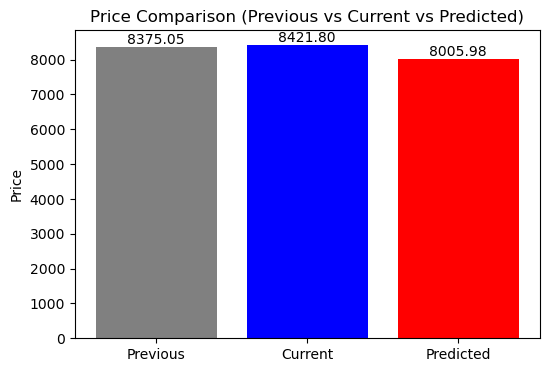

In [60]:
labels = ['Previous', 'Current', 'Predicted']
values = [previous_price, price, prediction]
colors = ['gray', 'blue', 'green' if prediction > price else 'red']

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=colors)
plt.title('Price Comparison (Previous vs Current vs Predicted)')
plt.ylabel('Price')

for i, v in enumerate(values):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.show()

In [53]:
def predict_nifty(price, open_price, high, low, volume, previous_price):

    change_pct = ((price - previous_price) / previous_price) * 100
    high_low_diff = high - low
    open_close_diff = price - open_price

    input_data = pd.DataFrame([[
        price,
        open_price,
        high,
        low,
        volume,
        change_pct,
        previous_price,
        high_low_diff,
        open_close_diff
    ]],columns=features)
    
    input_scaled = scaler.transform(input_data)

    prediction = rf_model.predict(input_scaled)[0]


    
    return prediction

In [54]:
price = float(input("Current Price: "))
open_price = float(input("Open: "))
high = float(input("High: "))
low = float(input("Low: "))
volume = float(input("Volume: "))
previous_price = float(input("Previous Price: "))

prediction = predict_nifty(
    price,
    open_price,
    high,
    low,
    volume,
    previous_price
)

print("\nPredicted Next-Day Price:", round(prediction, 2))
print("Current Price:", round(price, 2))
print("Expected Change %:", round(((prediction-price)/price)*100, 2))

Current Price:  8421.80
Open:  8417
High:  8458.90
Low:  8408.30
Volume:  221.94
Previous Price:  8375.05



Predicted Next-Day Price: 8028.34
Current Price: 8421.8
Expected Change %: -4.67


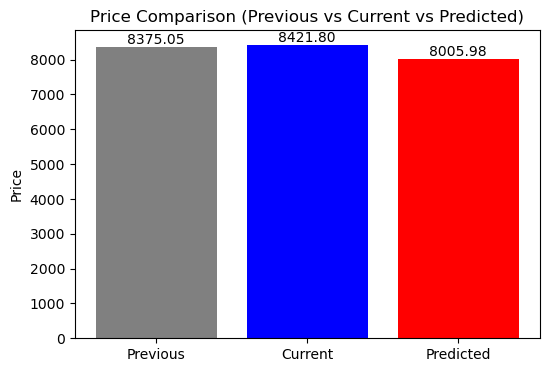

In [62]:
labels = ['Previous', 'Current', 'Predicted']
values = [previous_price, price, prediction]
colors = ['gray', 'blue', 'green' if prediction > price else 'red']

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=colors)
plt.title('Price Comparison (Previous vs Current vs Predicted)')
plt.ylabel('Price')

for i, v in enumerate(values):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.show()